In [ ]:
import scanpy as sc
import anndata as ad
import pandas as pd
import torch
import numpy as np
import UniDISA
rna = sc.read_h5ad("../Dataset/RNA+46ADT/rna.h5ad")
adt = sc.read_h5ad("../Dataset/RNA+46ADT/adt.h5ad")

# Set figure size for all subsequent plots
sc.settings.set_figure_params(dpi=100, figsize=(4, 4))

In [ ]:
##construct link feat
correspondence = pd.read_csv("..\Dataset\TEA-seq PBMC\protein_gene_conversion.csv")
correspondence['Protein name'] = correspondence['Protein name'].replace(to_replace={'TCRab': 'TCR-a/b', 'TCRgd': 'TCR-g/d'})
print(correspondence)

rna_protein_correspondence = []

for i in range(correspondence.shape[0]):
    curr_protein_name, curr_rna_names = correspondence.iloc[i]
    if curr_protein_name not in adt.var_names:
        continue
    if curr_rna_names.find('Ignore') != -1: # some correspondence ignored eg. protein isoform to one gene
        continue
    curr_rna_names = curr_rna_names.split('/') # eg. one protein to multiple genes
    for r in curr_rna_names:
        if r in rna.var_names:
            rna_protein_correspondence.append([r, curr_protein_name])

rna_protein_correspondence = np.array(rna_protein_correspondence)
RNA_shared = rna[:, rna_protein_correspondence[:, 0]].copy()
ADT_shared = adt[:, rna_protein_correspondence[:, 1]].copy()
RNA_shared.var['feature_name'] = RNA_shared.var.index.values
ADT_shared.var['feature_name'] = ADT_shared.var.index.values
RNA_shared.var_names_make_unique()
ADT_shared.var_names_make_unique()

RNA_counts = RNA_shared.X.sum(axis=1)
ADT_counts = ADT_shared.X.sum(axis=1)
target_sum = np.maximum(np.median(np.array(RNA_counts).copy()), 20)

sc.pp.normalize_total(RNA_shared, target_sum=target_sum)
sc.pp.log1p(RNA_shared)
sc.pp.scale(RNA_shared, max_value=10)

sc.pp.normalize_total(ADT_shared, target_sum=target_sum)
sc.pp.log1p(ADT_shared)
sc.pp.scale(ADT_shared, max_value=10)

rna.obsm['link_feat'] = RNA_shared.X
adt.obsm['link_feat'] = ADT_shared.X


      Protein name                   RNA name
0             CD80                       CD80
1             CD86                       CD86
2            CD274                      CD274
3            CD273                   PDCD1LG2
4            CD275                     ICOSLG
..             ...                        ...
336         HLA.DR  HLA-DRA/HLA-DRB1/HLA-DRB3
337  TCR.Va24.Ja18       Ignore: isoform skip
338      TCR.Va7.2       Ignore: isoform skip
339        TCR.a.b                    TRA/TRB
340        TCR.g.d                    TRG/TRD

[341 rows x 2 columns]


c:\Users\Administrator\miniconda3\envs\mycode\lib\site-packages\anndata\_core\anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
c:\Users\Administrator\miniconda3\envs\mycode\lib\site-packages\anndata\_core\anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
c:\Users\Administrator\miniconda3\envs\mycode\lib\site-packages\legacy_api_wrap\__init__.py:82: UserWarning: Some cells have zero counts
  return fn(*args_all, **kw)
c:\Users\Administrator\miniconda3\envs\mycode\lib\functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


In [3]:
##preprocess input
#rna
sc.pp.highly_variable_genes(rna, flavor='seurat_v3', n_top_genes=2000, subset=True)
sc.pp.normalize_total(rna)
sc.pp.log1p(rna)
sc.pp.scale(rna, max_value=10)
sc.pp.pca(rna, n_comps=15)

#adt
sc.pp.normalize_total(adt)
sc.pp.log1p(adt)
# mycode.utils.clr(adt)
sc.pp.scale(adt, max_value=10)
sc.pp.pca(adt, n_comps=15)

c:\Users\Administrator\miniconda3\envs\mycode\lib\functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


Model

In [4]:
model = UniDISA.IntegrationModel(rna, adt, input_key=[None, None])

Stage1

In [5]:
model.train_stage1(training_steps=3000,
                       lambdaRecon=10.0,
                       lambdaLA=1.0,
                       lambdaDA=1.0)
model.get_latent_representation()

===== Stage 1: Initial Alignment =====
[Stage1 0] AE: 1.9128 | LA: 0.1170 | DA: 0.1602
[Stage1 500] AE: 1.0422 | LA: 0.0036 | DA: 0.1919
[Stage1 1000] AE: 1.0133 | LA: 0.0032 | DA: 0.1626
[Stage1 1500] AE: 0.9836 | LA: 0.0028 | DA: 0.1598
[Stage1 2000] AE: 0.9570 | LA: 0.0029 | DA: 0.1524
[Stage1 2500] AE: 0.9585 | LA: 0.0030 | DA: 0.1566
[Stage1 3000] AE: 0.9654 | LA: 0.0035 | DA: 0.1510
Total time: 0.12s
Latent shape: (14874, 10)


c:\Users\Administrator\miniconda3\envs\mycode\lib\site-packages\anndata\_core\anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
c:\Users\Administrator\miniconda3\envs\mycode\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


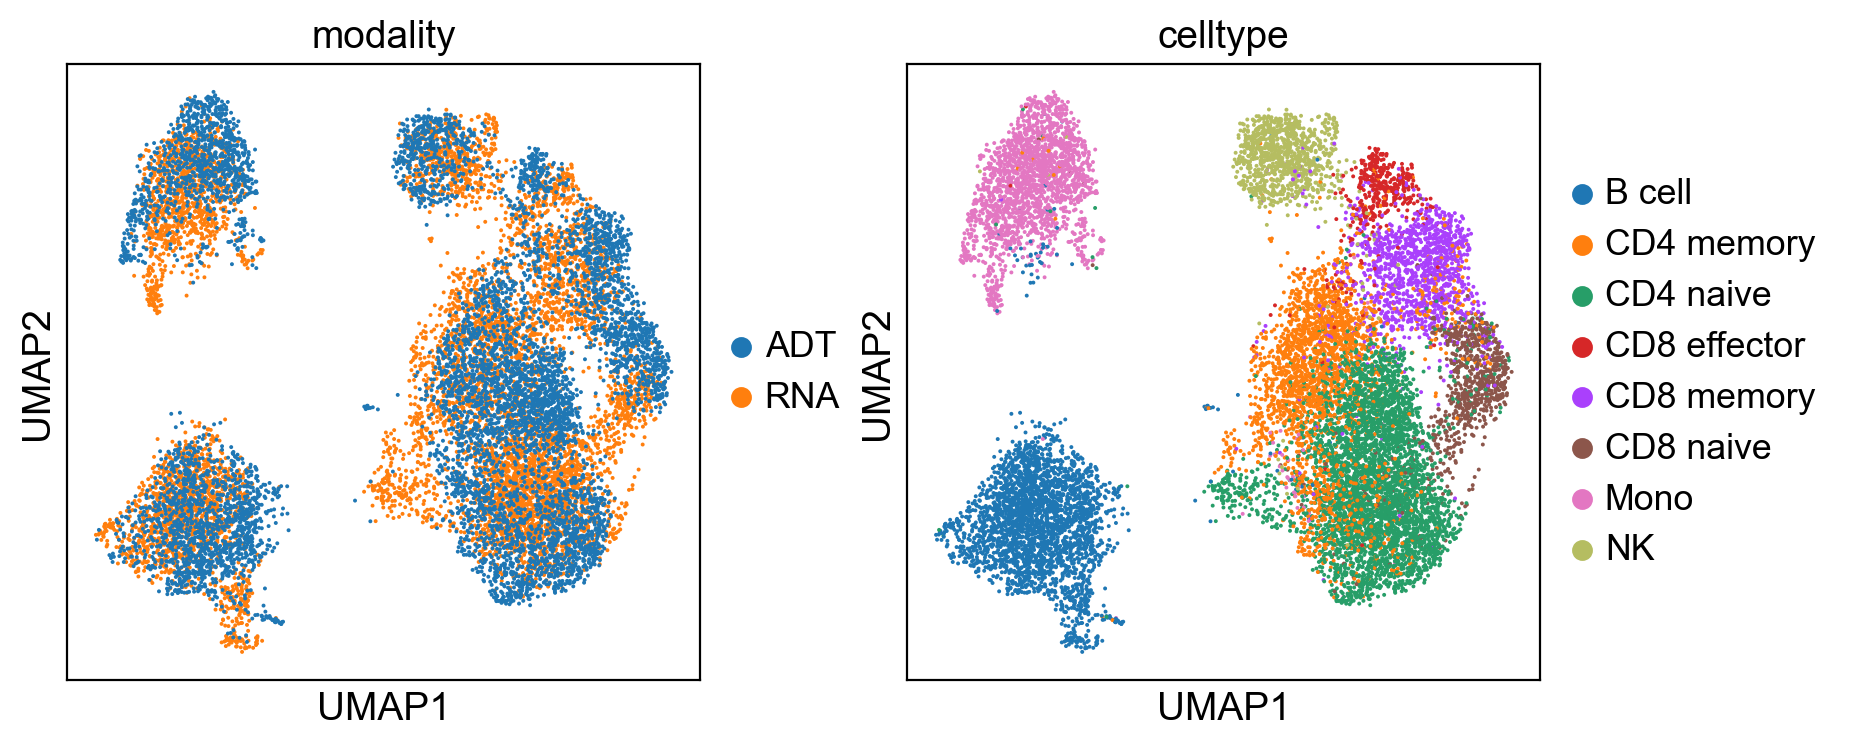

In [6]:
# Create integrated AnnData object
adata_integrated = ad.AnnData(
    X=model.latent,
    obs=pd.concat([rna.obs, adt.obs])
)
adata_integrated.obs['modality'] = ['RNA'] * rna.shape[0] + ['ADT'] * adt.shape[0]

# Dimensionality reduction and visualization
sc.pp.neighbors(adata_integrated)
sc.tl.umap(adata_integrated)
sc.pl.umap(adata_integrated, color=['modality', 'celltype'], ncols=2)

Stage2

In [7]:
model.train_stage2(training_steps=3000,
                       lambdaRecon=10.0,
                       lambdaLA=1.0,
                       lambdaDA=1.0,
                       n_iters=1)
model.get_latent_representation()

===== Stage 2: Iterative Alignment 1/1 =====
[Stage2 0] AE: 1.9313 | LA: 0.1081 | DA: 0.1320
[Stage2 500] AE: 1.0184 | LA: 0.0037 | DA: 0.1548
[Stage2 1000] AE: 0.9830 | LA: 0.0038 | DA: 0.1331
[Stage2 1500] AE: 0.9704 | LA: 0.0038 | DA: 0.1339
[Stage2 2000] AE: 0.9763 | LA: 0.0037 | DA: 0.1366
[Stage2 2500] AE: 0.9585 | LA: 0.0037 | DA: 0.1418
[Stage2 3000] AE: 0.9389 | LA: 0.0045 | DA: 0.1375
Total time: 0.11s
Latent shape: (14874, 10)


c:\Users\Administrator\miniconda3\envs\mycode\lib\site-packages\anndata\_core\anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


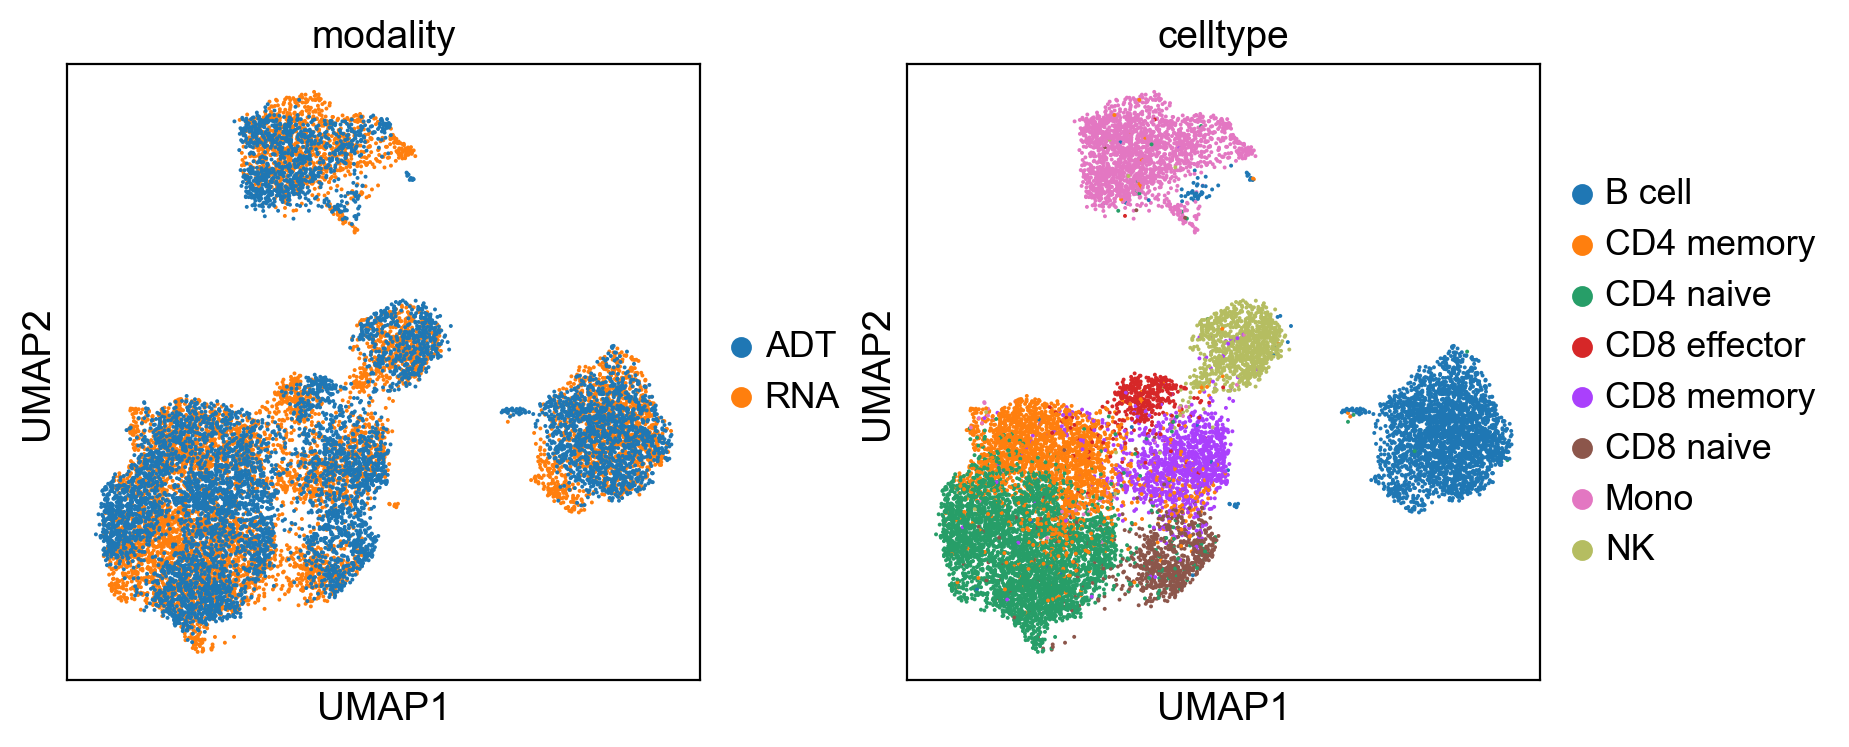

In [8]:
# Create integrated AnnData object
adata_integrated = ad.AnnData(
    X=model.latent,
    obs=pd.concat([rna.obs, adt.obs])
)
adata_integrated.obs['modality'] = ['RNA'] * rna.shape[0] + ['ADT'] * adt.shape[0]

# Dimensionality reduction and visualization
sc.pp.neighbors(adata_integrated)
sc.tl.umap(adata_integrated)
sc.pl.umap(adata_integrated, color=['modality', 'celltype'], ncols=2)

Stage3

In [9]:
model.train_stage3(
    training_steps=10000,
    lambdaRecon=10.0,
    lambdaLA=10.0,
    lambdaDA=1.0,
    lambdamGAN=1.0,
    use_mGAN=True)
model.get_latent_representation()

===== Stage 3: Final Alignment =====
[Stage3 0] AE: 1.9049 | LA: 0.1160 | DA: 0.1332 | mGAN: -1.2346 | bGAN: 0.0000
[Stage3 1000] AE: 1.0086 | LA: 0.0028 | DA: 0.1113 | mGAN: -1.3694 | bGAN: 0.0000
[Stage3 2000] AE: 0.9784 | LA: 0.0051 | DA: 0.0978 | mGAN: -1.3321 | bGAN: 0.0000
[Stage3 3000] AE: 0.9628 | LA: 0.0044 | DA: 0.0899 | mGAN: -1.3172 | bGAN: 0.0000
[Stage3 4000] AE: 0.9739 | LA: 0.0048 | DA: 0.0970 | mGAN: -1.2722 | bGAN: 0.0000
[Stage3 5000] AE: 0.9756 | LA: 0.0039 | DA: 0.0887 | mGAN: -1.2698 | bGAN: 0.0000
[Stage3 6000] AE: 0.9546 | LA: 0.0036 | DA: 0.0943 | mGAN: -1.2604 | bGAN: 0.0000
[Stage3 7000] AE: 0.9487 | LA: 0.0041 | DA: 0.1078 | mGAN: -1.2556 | bGAN: 0.0000
[Stage3 8000] AE: 0.9383 | LA: 0.0038 | DA: 0.0994 | mGAN: -1.2620 | bGAN: 0.0000
[Stage3 9000] AE: 0.9345 | LA: 0.0034 | DA: 0.0980 | mGAN: -1.2989 | bGAN: 0.0000
[Stage3 10000] AE: 0.9310 | LA: 0.0036 | DA: 0.1040 | mGAN: -1.2825 | bGAN: 0.0000
Total time: 0.11s
Latent shape: (14874, 10)


c:\Users\Administrator\miniconda3\envs\mycode\lib\site-packages\anndata\_core\anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


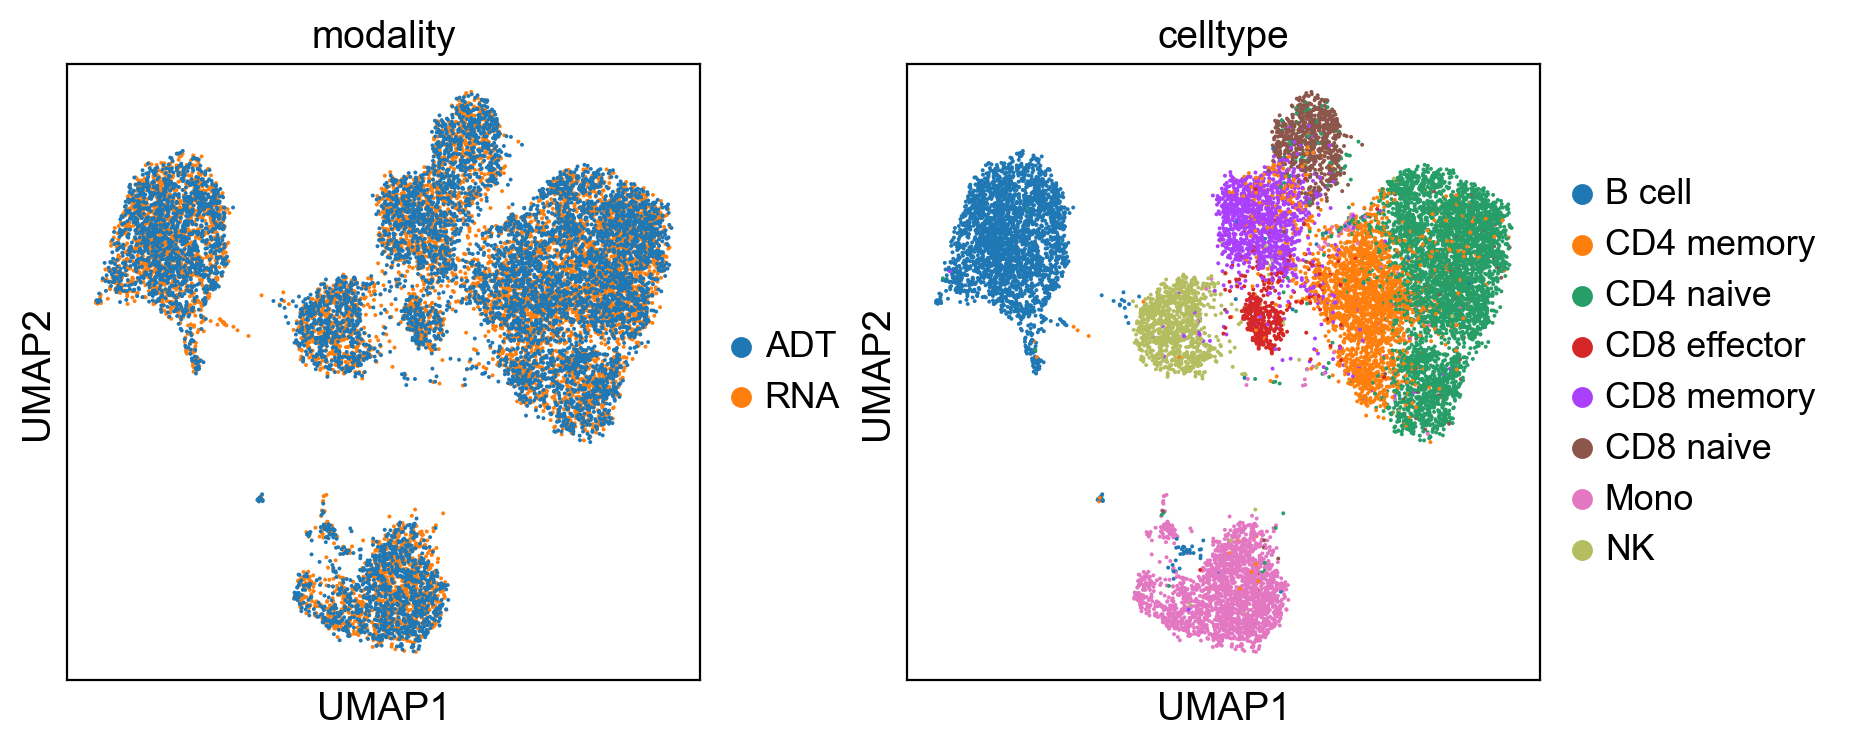

In [10]:
# Create integrated AnnData object
adata_integrated = ad.AnnData(
    X=model.latent,
    obs=pd.concat([rna.obs, adt.obs])
)
adata_integrated.obs['modality'] = ['RNA'] * rna.shape[0] + ['ADT'] * adt.shape[0]

# Dimensionality reduction and visualization
sc.pp.neighbors(adata_integrated)
sc.tl.umap(adata_integrated)
sc.pl.umap(adata_integrated, color=['modality', 'celltype'], ncols=2)

In [11]:
acc, f1 = UniDISA.metrics.calculate_shared_type_transfer_metrics(adata_integrated, batch_key='modality', label_key='celltype', embed="X_emb")

from scib_metrics.benchmark import Benchmarker, BioConservation, BatchCorrection
adata_integrated.obsm['X_emb'] = adata_integrated.X
%matplotlib inline
bm = Benchmarker(
    adata_integrated,
    batch_key="modality",
    label_key="celltype",
    bio_conservation_metrics=BioConservation(silhouette_label=False),
    batch_correction_metrics=BatchCorrection(pcr_comparison=False),
    embedding_obsm_keys=["X_umap", "X_emb"],
    n_jobs=6,
)
bm.benchmark()

c:\Users\Administrator\miniconda3\envs\mycode\lib\site-packages\scanpy\preprocessing\_pca\__init__.py:227: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(
c:\Users\Administrator\miniconda3\envs\mycode\lib\site-packages\anndata\_core\anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
c:\Users\Administrator\miniconda3\envs\mycode\lib\site-packages\anndata\_core\anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
Embeddings:   0%|          | 0/2 [00:00<?, ?it/s]c:\Users\Administrator\miniconda3\envs\mycode\lib\site-packages\scib_metrics\metrics\_kbet.py:182: Depr

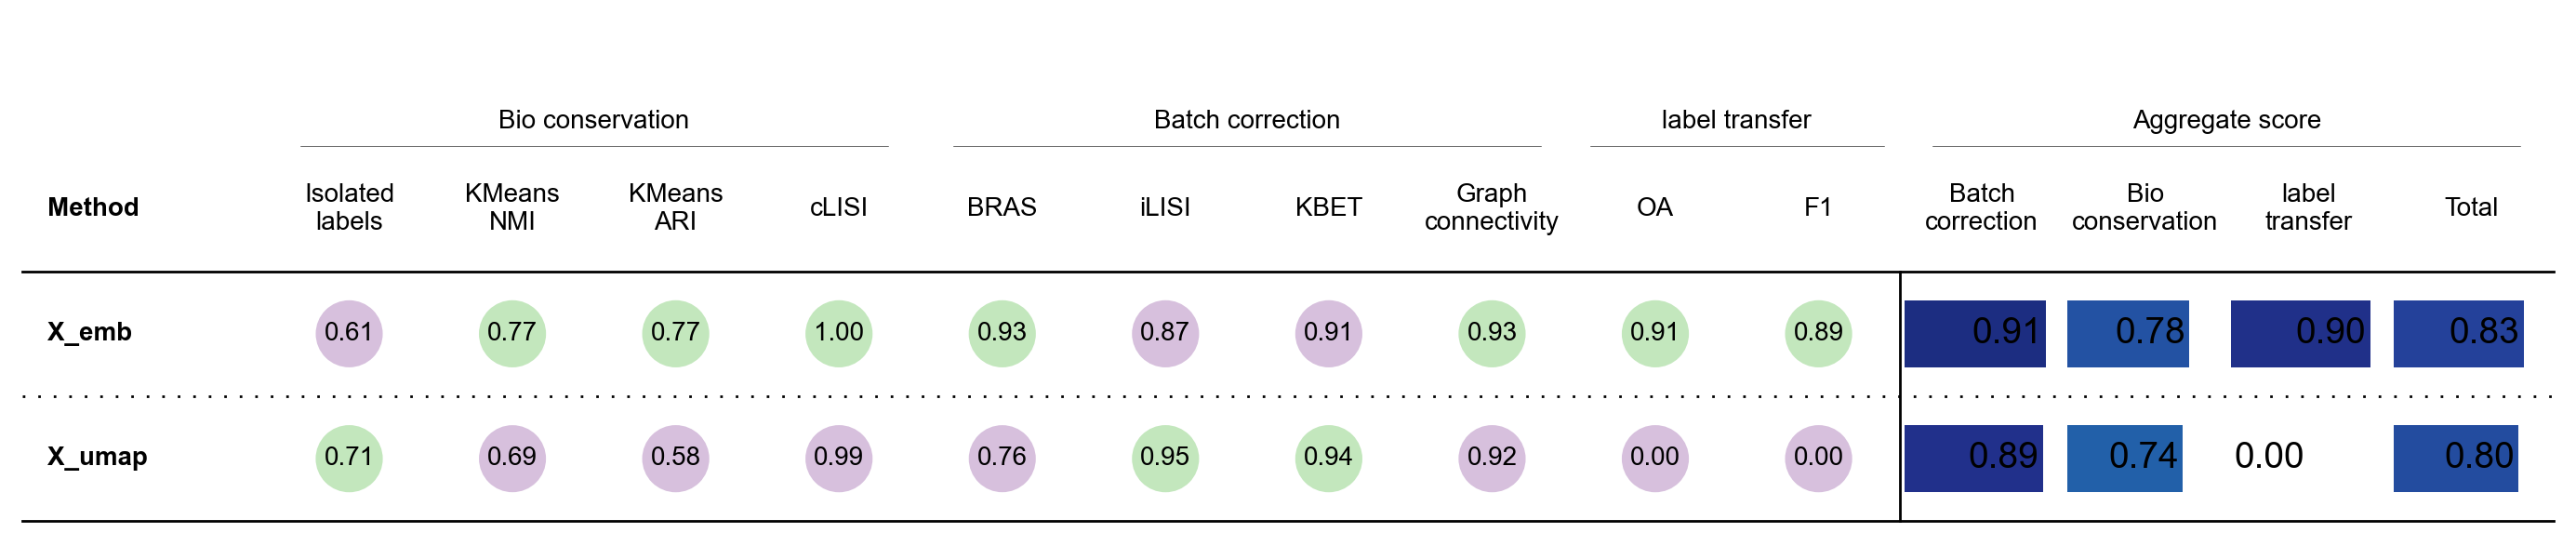

In [12]:
bm._results.loc['OA'] = {
    "X_umap": 0.0,
    "X_emb": acc,
    "Metric Type": "label transfer"
}
bm._results.loc['F1'] = {
    "X_umap": 0.0,
    "X_emb": f1,
    "Metric Type": "label transfer"
}
bm.plot_results_table(min_max_scale=False)